# Chapter 4, Example 2: The Gibbs Variational Principle

For a finite state space and temperature $T>0$, define

$$
p_T(\boldsymbol{x})=\frac{\exp(-E(\boldsymbol{x})/T)}{Z_T}.
$$

For any trial probability distribution $q$, the Gibbs free-energy functional is

$$
\mathcal{F}_T(q)=\mathbb{E}_q[E]-T\mathcal{H}(q),
$$

where

$$
\mathcal{H}(q)=-\sum_{\boldsymbol{x}}q(\boldsymbol{x})\log q(\boldsymbol{x}).
$$

The exact identity

$$
\mathcal{F}_T(q)=-T\log Z_T+T\,D_{\mathrm{KL}}(q\|p_T)
$$

implies that $p_T$ is the unique minimizer whenever it has full support. This notebook verifies the identity and demonstrates numerical optimization over the probability simplex.

In [1]:
from pathlib import Path
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from scipy.optimize import minimize

CWD = Path.cwd()
if CWD.name == "ch04":
    NOTEBOOK_DIR = CWD
elif (CWD / "notebooks" / "ch04").exists():
    NOTEBOOK_DIR = CWD / "notebooks" / "ch04"
else:
    NOTEBOOK_DIR = CWD
FIG_DIR = NOTEBOOK_DIR / "figs"
FIG_DIR.mkdir(parents=True, exist_ok=True)
RNG = np.random.default_rng(577)

plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
    "figure.titlesize": 19,
    "lines.linewidth": 2.2,
})

DARK_NODE = "#315a78"
FACTOR_NODE = "#6b4c7a"


def save_figure(fig, stem: str) -> None:
    """Save a Matplotlib figure as both vector PDF and high-resolution PNG."""
    pdf_path = FIG_DIR / f"{stem}.pdf"
    png_path = FIG_DIR / f"{stem}.png"
    fig.savefig(pdf_path, bbox_inches="tight")
    fig.savefig(png_path, dpi=240, bbox_inches="tight")
    print(f"Saved: {pdf_path}")
    print(f"Saved: {png_path}")


def annotate_heatmap(ax, image, matrix, fmt=".2f"):
    """Use white text on dark cells and black text on light cells."""
    norm = image.norm
    cmap = image.cmap
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            rgba = cmap(norm(matrix[i, j]))
            luminance = 0.2126 * rgba[0] + 0.7152 * rgba[1] + 0.0722 * rgba[2]
            color = "black" if luminance > 0.58 else "white"
            ax.text(j, i, format(matrix[i, j], fmt), ha="center", va="center",
                    color=color, fontsize=12, fontweight="bold")


# The same four-spin chain used in Chapter 2.
STATES = np.array(list(product([-1, 1], repeat=4)), dtype=int)
TRUE = {
    "h": np.array([0.35, -0.15, 0.20, -0.30]),
    "J": np.array([0.85, -0.55, 0.70]),
}


def energy(states, h=TRUE["h"], J=TRUE["J"]):
    states = np.atleast_2d(states)
    unary = -(states @ h)
    pair = -(J[0] * states[:, 0] * states[:, 1]
             + J[1] * states[:, 1] * states[:, 2]
             + J[2] * states[:, 2] * states[:, 3])
    return unary + pair


def distribution_at_temperature(T=1.0, h=TRUE["h"], J=TRUE["J"]):
    E = energy(STATES, h=h, J=J)
    shifted = -(E - E.min()) / T
    weights = np.exp(shifted)
    p = weights / weights.sum()
    logZ = -E.min() / T + np.log(weights.sum())
    return p, E, logZ


def label_state(x):
    return "(" + ",".join("+" if v == 1 else "-" for v in x) + ")"

## 1. Free energy, entropy, and KL divergence

We build a one-parameter path from the uniform distribution to the exact Gibbs distribution:

$$
q_\alpha=(1-\alpha)u+\alpha p_T,
\qquad 0\leq\alpha\leq 1.
$$

Along this path, the free-energy gap must equal $T D_{\mathrm{KL}}(q_\alpha\|p_T)$.

Saved: figs/ch04_02_free_energy_kl_identity.pdf
Saved: figs/ch04_02_free_energy_kl_identity.png


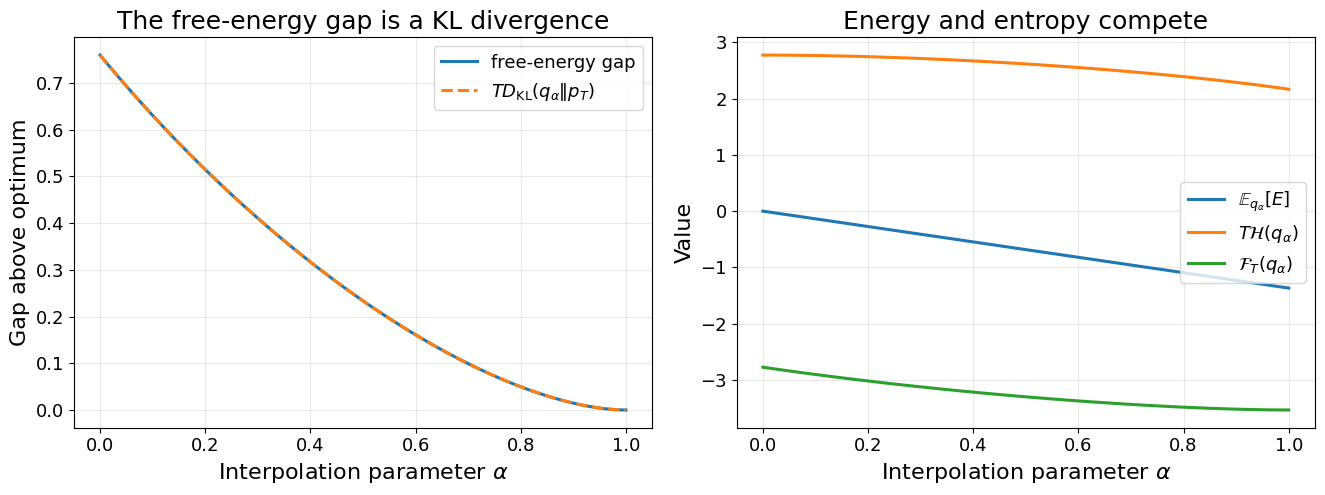

In [2]:
T = 1.0
p, E, logZ = distribution_at_temperature(T=T)
uniform = np.ones_like(p) / len(p)
alphas = np.linspace(0, 1, 101)
free_energy = []
kl_values = []
energies = []
entropies = []
for alpha in alphas:
    q = (1-alpha) * uniform + alpha * p
    H = -np.sum(q * np.log(q))
    EqE = np.sum(q * E)
    KL = np.sum(q * np.log(q / p))
    energies.append(EqE)
    entropies.append(H)
    free_energy.append(EqE - T * H)
    kl_values.append(KL)
free_energy = np.array(free_energy)
kl_values = np.array(kl_values)
exact_min = -T * logZ
assert np.max(np.abs((free_energy - exact_min) - T * kl_values)) < 1e-11

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2))
axes[0].plot(alphas, free_energy - exact_min, label="free-energy gap")
axes[0].plot(alphas, T * kl_values, linestyle="--", label=r"$T D_{\mathrm{KL}}(q_\alpha\|p_T)$")
axes[0].set_xlabel(r"Interpolation parameter $\alpha$")
axes[0].set_ylabel("Gap above optimum")
axes[0].set_title("The free-energy gap is a KL divergence")
axes[0].legend()
axes[0].grid(alpha=0.28)

axes[1].plot(alphas, energies, label=r"$\mathbb{E}_{q_\alpha}[E]$")
axes[1].plot(alphas, T*np.array(entropies), label=r"$T\mathcal{H}(q_\alpha)$")
axes[1].plot(alphas, free_energy, label=r"$\mathcal{F}_T(q_\alpha)$")
axes[1].set_xlabel(r"Interpolation parameter $\alpha$")
axes[1].set_ylabel("Value")
axes[1].set_title("Energy and entropy compete")
axes[1].legend()
axes[1].grid(alpha=0.28)
fig.tight_layout()
save_figure(fig, "ch04_02_free_energy_kl_identity")
plt.show()

## 2. Direct optimization on the simplex

A probability vector can be parameterized by unconstrained logits $r$ through the softmax map

$$
q_i(r)=\frac{\exp(r_i)}{\sum_j\exp(r_j)}.
$$

We minimize the exact free energy using a generic optimizer. The result should recover $p_T$. This calculation is intentionally small: in a realistic graphical model, the vector $q$ has exponentially many entries, motivating the structured approximations developed later.

Desired error not necessarily achieved due to precision loss.
Maximum probability error: 2.698872328399382e-08


Saved: figs/ch04_02_variational_optimization.pdf
Saved: figs/ch04_02_variational_optimization.png


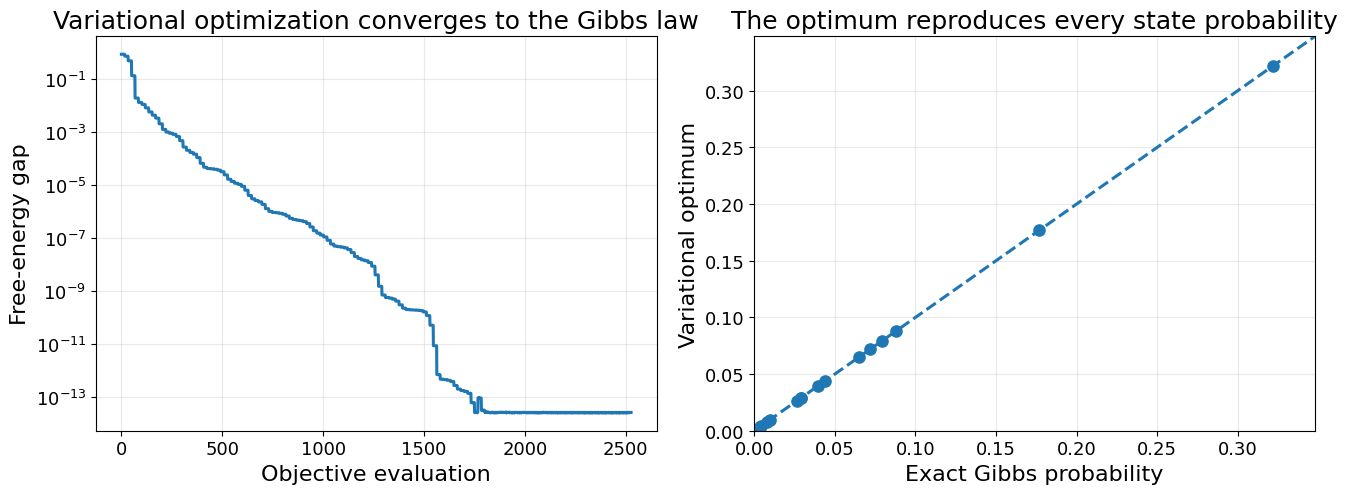

In [3]:
def softmax(r):
    shifted = r - np.max(r)
    e = np.exp(shifted)
    return e / e.sum()

history = []
def objective(r):
    q = softmax(r)
    value = np.sum(q * E) + T * np.sum(q * np.log(q + 1e-300))
    history.append(value)
    return value

r0 = RNG.normal(scale=0.4, size=len(p))
result = minimize(objective, r0, method="BFGS", options={"gtol":1e-10, "maxiter":1000})
q_star = softmax(result.x)
print(result.message)
print("Maximum probability error:", np.max(np.abs(q_star-p)))
assert np.max(np.abs(q_star-p)) < 2e-6

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2))
axes[0].plot(np.array(history) - exact_min)
axes[0].set_yscale("log")
axes[0].set_xlabel("Objective evaluation")
axes[0].set_ylabel("Free-energy gap")
axes[0].set_title("Variational optimization converges to the Gibbs law")
axes[0].grid(alpha=0.28)

axes[1].scatter(p, q_star, s=65)
upper = max(p.max(), q_star.max()) * 1.08
axes[1].plot([0,upper],[0,upper], linestyle="--")
axes[1].set_xlim(0,upper)
axes[1].set_ylim(0,upper)
axes[1].set_xlabel("Exact Gibbs probability")
axes[1].set_ylabel("Variational optimum")
axes[1].set_title("The optimum reproduces every state probability")
axes[1].grid(alpha=0.28)
fig.tight_layout()
save_figure(fig, "ch04_02_variational_optimization")
plt.show()

## 3. Why this exact variational principle is not yet an algorithm

The exact trial distribution $q$ has one component for every global state. For $N$ binary variables, it therefore has $2^N$ entries. Later chapters replace this global object by tractable families or collections of local beliefs. Mean-field, Bethe, Kikuchi, and generalized belief-propagation methods differ primarily in which local objects they retain and how they approximate entropy and consistency.

## Exercises

1. Repeat the calculation for several temperatures and compare the conditioning of the optimization problem.
2. Restrict $q$ to a product distribution and minimize the resulting mean-field free energy. Quantify the approximation error.
3. Replace the KL divergence by its reverse orientation $D_{\mathrm{KL}}(p_T\|q)$ and explain why the resulting objective is no longer the Gibbs free energy.
4. Construct a zero-probability hard constraint and identify the additional care needed when evaluating $D_{\mathrm{KL}}(q\|p_T)$.